<a href="https://colab.research.google.com/github/JuanAndrewD/RMCT_Assignment_Codebase/blob/main/Institutional_Algorithmic_Trading_Strategy-RMCT-Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Systematic Benchmark of Institutional Algorithmic Trading Strategy: Quantitative Mean Reversion and Volatility-Adjusted Execution Logic**

This notebook contains the implementation and empirical validation of a popular Institutional Algorithmic Trading Strategy: Quantitative Mean Reversion and Volatility-Adjusted Execution Logic.

The primary goal of this specific module is to address the challenges in institutional trading by:
1. Implementing mean reversion signals based on statistical measures like z-score from moving averages.
2. Adjusting execution logic based on volatility to optimize trade timing and sizing.
3. Backtesting the strategy using high-frequency historical data ($SPY$).
4. Statistically Validating whether the mean reversion signals hold predictive power for future returns.

### **Code Implementation & Methodology**

This Python implementation utilizes yfinance for data acquisition and statsmodels for OLS (Ordinary Least Squares) regression analysis.

**What this code does:**
* Data Acquisition: Fetches historical OHLCV data for a specified ticker (default: $SPY$) and interval.
* Mean Reversion Signal Generation: Calculates z-score based on moving average deviations to identify overbought/oversold conditions.
* Volatility Adjustment: Uses Average True Range (ATR) to adjust position sizes based on market volatility.
* Regression Analysis: Performs an OLS regression between the mean reversion signals and the N-period forward price change to determine if the signals correlate with future returns.
* Statistical Validation:
  * Residual Analysis: Tests for linearity, homoscedasticity, and normality.
  * Permutation Testing (Monte Carlo): Shuffles the target variable $100,000$ times to create a Null Distribution of correlation coefficients, allowing us to see if the "Real Correlation" is statistically significant or happened by chance.
* Backtesting & Performance Analytics: Backtest engine evaluates the economic utility of the regression model over the last 5 years. Measures the strategy's annualized return in excess of the $SPY$ benchmark.

### **Install and Load All of the Required Library**

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pandas.plotting import lag_plot

### **Implementation of Discretization Logic for Fair Value Gap (FVG) Detection**

[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:      5 Period % Change   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     20.59
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           5.78e-06
Time:                        13:36:04   Log-Likelihood:                 19276.
No. Observations:                8315   AIC:                        -3.855e+04
Df Residuals:                    8313   BIC:                        -3.853e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.00

Price,Adj Close,Close,High,Low,Open,Volume,Close + 5,5 Period % Change,MA,STD,...,Low_Close,TR,ATR,Signal,Vol_Adj_Factor,Position_Size,Adjusted_Signal,Mean_Reversion_Signal,Predictions,Residuals
0,24.175383,43.937500,43.968750,43.750000,43.968750,1003200,44.96875,0.023471,NaN,NaN,...,NaN,0.218750,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,24.347324,44.250000,44.250000,43.968750,43.968750,480500,44.96875,0.016243,NaN,NaN,...,0.031250,0.312500,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,24.398905,44.343750,44.375000,44.125000,44.218750,201300,44.65625,0.007047,NaN,NaN,...,0.125000,0.250000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
3,24.656822,44.812500,44.843750,44.375000,44.406250,529400,44.71875,-0.002092,NaN,NaN,...,0.031250,0.500000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
4,24.759977,45.000000,45.093750,44.468750,44.968750,531500,44.93750,-0.001389,NaN,NaN,...,0.343750,0.625000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8347,631.969971,631.969971,640.369995,629.280029,640.109985,99275900,NaN,NaN,663.271503,15.327505,...,4.809998,11.089966,9.988578,1,0.989727,0.989727,0.989727,0.989727,0.005908,NaN
8348,650.340027,650.340027,651.539978,637.979980,638.940002,152534100,NaN,NaN,661.772003,15.035005,...,6.010010,19.570007,10.905007,0,0.914472,0.914472,0.000000,0.000000,0.001903,NaN
8349,655.239990,655.239990,658.520020,653.000000,653.900024,97841500,NaN,NaN,660.277502,14.043872,...,2.659973,8.179993,10.742148,0,0.935780,0.935780,0.000000,0.000000,0.001903,NaN
8350,655.830017,655.830017,658.200012,645.109985,646.419983,68358700,NaN,NaN,659.003503,13.163604,...,10.130005,13.090027,10.892862,0,0.932525,0.932525,0.000000,0.000000,0.001903,NaN


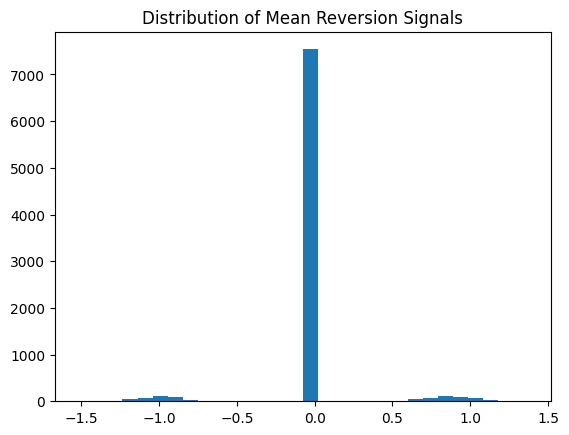

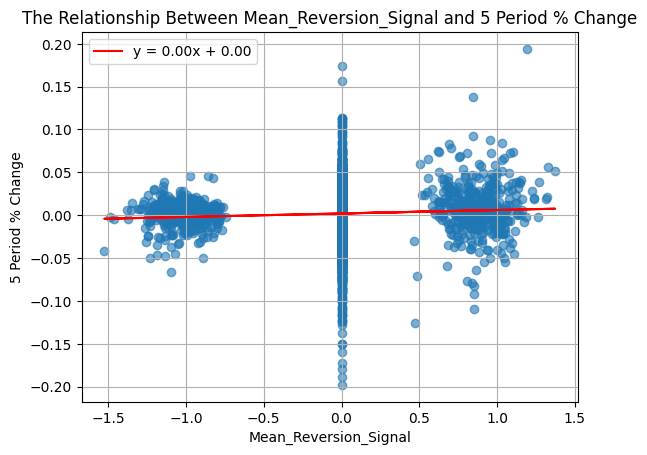

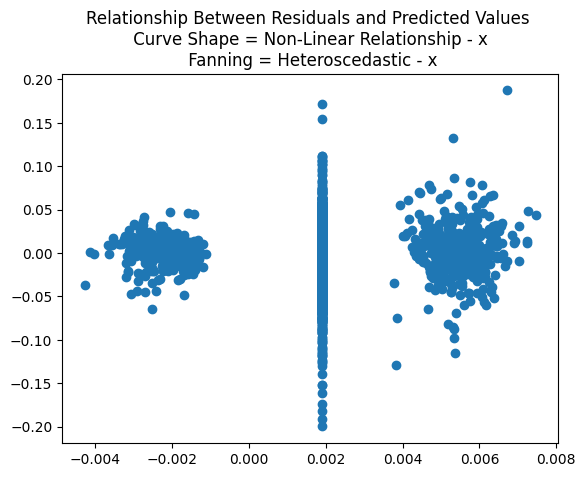

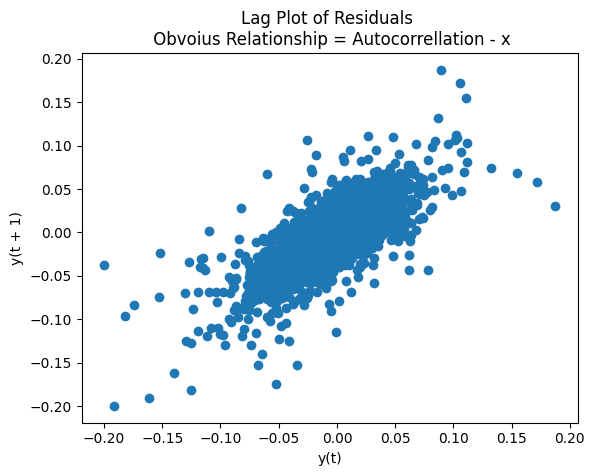

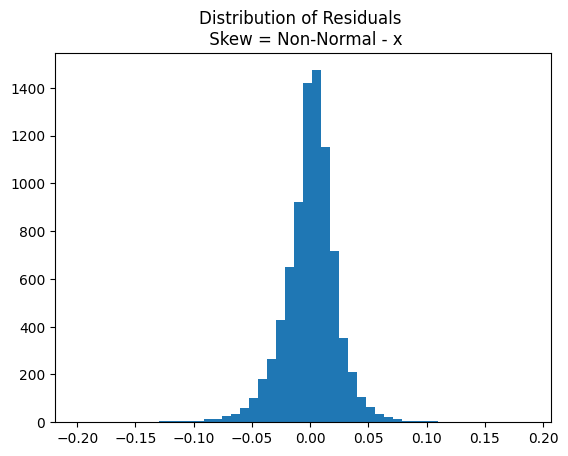

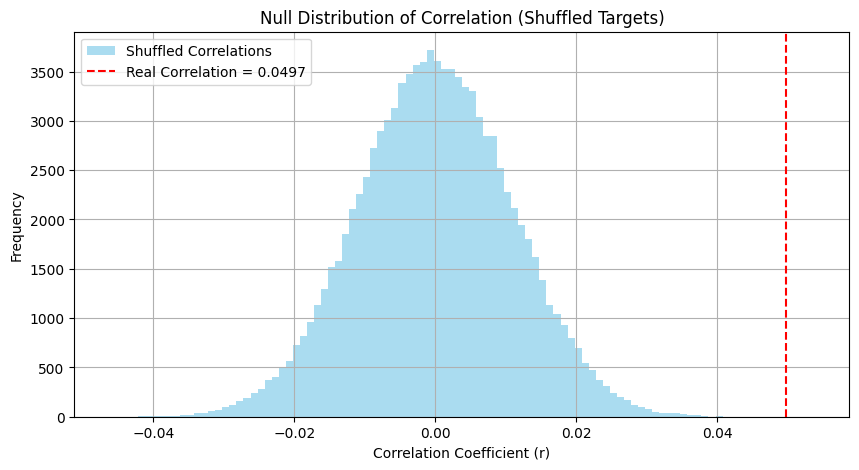

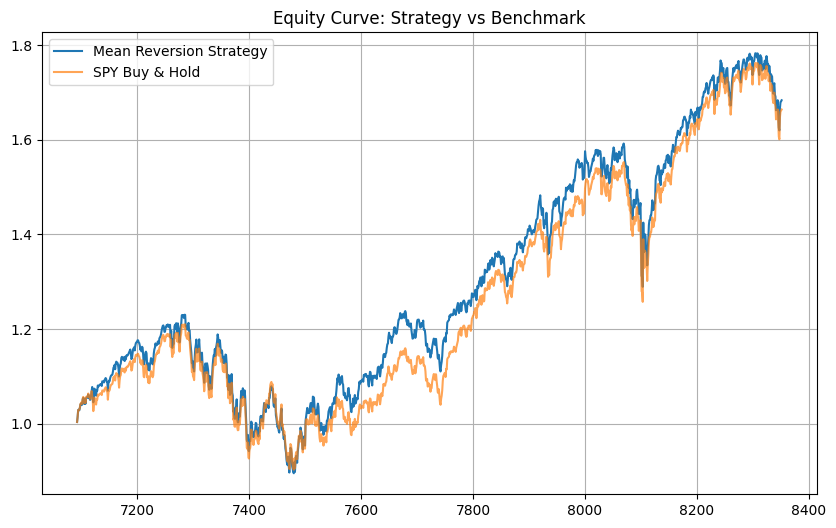

In [3]:
TICKER = 'SPY'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

SHIFT = 5
STRATEGY = 'Mean_Reversion_Signal'

# what subsetion of that data are you interested in
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

# define the target variable (also called dependent variable, or y)
def add_target(df, shift=SHIFT):

    # what is the close price SHIFT days from now?
    df[f'Close + {shift}'] = df['Close'].shift(-shift)

    # what is the change in close price SHIFT days from now?
    df[f'{shift} Period % Change'] = (df[f'Close + {shift}'] - df['Close']) / df['Close']

    return df

def calculate_moving_average(df, window=20):
    df['MA'] = df['Close'].rolling(window=window).mean()
    return df

def calculate_z_score(df, window=20):
    df['MA'] = df['Close'].rolling(window=window).mean()
    df['STD'] = df['Close'].rolling(window=window).std()
    df['Z_Score'] = (df['Close'] - df['MA']) / df['STD']
    return df

def calculate_atr(df, window=14):
    df['High_Low'] = df['High'] - df['Low']
    df['High_Close'] = (df['High'] - df['Close'].shift(1)).abs()
    df['Low_Close'] = (df['Low'] - df['Close'].shift(1)).abs()
    df['TR'] = df[['High_Low', 'High_Close', 'Low_Close']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=window).mean()
    return df

def generate_mean_reversion_signal(df, z_threshold=2.0):
    df['Signal'] = 0
    df.loc[df['Z_Score'] < -z_threshold, 'Signal'] = 1  # Buy signal (oversold)
    df.loc[df['Z_Score'] > z_threshold, 'Signal'] = -1  # Sell signal (overbought)
    return df

def volatility_adjusted_position(df, base_position=1.0):
    # Adjust position size inversely to volatility
    df['Vol_Adj_Factor'] = df['ATR'].rolling(window=20).mean() / df['ATR']
    df['Position_Size'] = base_position * df['Vol_Adj_Factor']
    df['Adjusted_Signal'] = df['Signal'] * df['Position_Size']
    return df

def prepare_dataframe_for_regression(df):
    df = calculate_z_score(df)
    df = calculate_atr(df)
    df = generate_mean_reversion_signal(df)
    df = volatility_adjusted_position(df)
    df['Mean_Reversion_Signal'] = df['Adjusted_Signal']

    plt.figure()
    plt.hist(df['Mean_Reversion_Signal'].dropna(), bins=30)
    plt.title('Distribution of Mean Reversion Signals')

    return df

def generate_regression_output(df, features='Mean_Reversion_Signal', target=f'{SHIFT} Period % Change'):
    subset = df[[features, target]].dropna()

    X = subset[features]
    y = subset[target]

    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()

    intercept = model.params['const']
    coefficient = model.params[features]
    y_pred = model.predict(X_with_const)

    # Console summary
    print(model.summary())

    # Plot
    plt.figure()
    plt.title(f'The Relationship Between {features} and {target}')
    plt.plot(X, y_pred, color='red', label=f'y = {coefficient:.2f}x + {intercept:.2f}')
    plt.scatter(X, y, alpha=0.6)
    plt.xlabel(f"{features}")
    plt.ylabel(f"{target}")
    plt.legend()
    plt.grid(True)

    return df, intercept, coefficient

def validate_regression_output(df, coef, intercept):

    # information necessary
    df['Predictions'] = coef * df['Mean_Reversion_Signal'] + intercept
    df['Residuals'] = df[f'{SHIFT} Period % Change'] - df['Predictions']

    # plot for linearity/homoscedasticity
    plt.figure()
    plt.scatter(df['Predictions'], df['Residuals'])
    plt.title('Relationship Between Residuals and Predicted Values \n ' \
        'Curve Shape = Non-Linear Relationship - x \n ' \
        'Fanning = Heteroscedastic - x')

    # plot for autocorrelations
    plt.figure()
    lag_plot(df['Residuals'].dropna())
    plt.title('Lag Plot of Residuals \n Obvoius Relationship = Autocorrellation - x')

    # plot for normality
    plt.figure()
    plt.hist(df['Residuals'], bins=50)
    plt.title('Distribution of Residuals \n Skew = Non-Normal - x')

    return df

def assess_regression_output(df, coef, features='Mean_Reversion_Signal', target=f'{SHIFT} Period % Change', n=100000):
    subset = df[[features, target]].dropna()
    X = subset[features]
    y = subset[target]

    real_r = np.corrcoef(X, y)[0, 1]
    correlations = []

    for _ in range(n):
        shuffled_y = np.random.permutation(y)
        r = np.corrcoef(X, shuffled_y)[0, 1]
        correlations.append(r)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.hist(correlations, bins=100, alpha=0.7, color='skyblue', label='Shuffled Correlations')
    plt.axvline(real_r, color='red', linestyle='--', label=f'Real Correlation = {real_r:.4f}')
    plt.title('Null Distribution of Correlation (Shuffled Targets)')
    plt.xlabel('Correlation Coefficient (r)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

    return df

def backtest_strategy(df, years=5):
    # 1. Filter for the last 5 years based on the original data timeframe
    days_to_lookback = years * 252
    backtest_df = df.iloc[-days_to_lookback:].copy()

    # 2. Generate Signals
    # Signal = 1 if predicted change is positive, -1 if negative (Simple Linear Strategy)
    backtest_df['Signal'] = np.where(backtest_df['Predictions'] > 0, 1, -1)

    # 3. Calculate Returns
    backtest_df['Market_Returns'] = backtest_df['Close'].pct_change()

    # Strategy returns: Signal of "today" acts on "tomorrow's" market return
    backtest_df['Strategy_Returns'] = backtest_df['Signal'].shift(1) * backtest_df['Market_Returns']
    backtest_df = backtest_df.dropna(subset=['Strategy_Returns', 'Market_Returns'])

    # 4. Calculate Performance Metrics
    risk_free_rate = 0.0  # Adjust as needed (e.g., 0.04 for 4%)

    # Cumulative Returns
    cum_strategy_rtn = (1 + backtest_df['Strategy_Returns']).prod() - 1
    cum_market_rtn = (1 + backtest_df['Market_Returns']).prod() - 1

    # Annualized Returns
    ann_strategy_rtn = (1 + cum_strategy_rtn)**(252 / len(backtest_df)) - 1
    ann_market_rtn = (1 + cum_market_rtn)**(252 / len(backtest_df)) - 1

    # Annualized Volatility
    ann_vol = backtest_df['Strategy_Returns'].std() * np.sqrt(252)

    # Alpha (Excess return over benchmark)
    alpha = ann_strategy_rtn - ann_market_rtn

    # Sharpe Ratio
    sharpe = (ann_strategy_rtn - risk_free_rate) / ann_vol

    # Sortino Ratio
    downside_std = backtest_df[backtest_df['Strategy_Returns'] < 0]['Strategy_Returns'].std() * np.sqrt(252)
    sortino = (ann_strategy_rtn - risk_free_rate) / downside_std

    # Print Results
    print("\n--- Backtest Results (Last 5 Years) ---")
    print(f"Annualized Alpha:   {alpha:.2%}")
    print(f"Sharpe Ratio:       {sharpe:.2f}")
    print(f"Sortino Ratio:      {sortino:.2f}")
    print(f"Strategy Total Rtn: {cum_strategy_rtn:.2%}")
    print(f"Market Total Rtn:   {cum_market_rtn:.2%}")

    # Plot Equity Curve
    plt.figure(figsize=(10, 6))
    ((1 + backtest_df['Strategy_Returns']).cumprod()).plot(label='Mean Reversion Strategy')
    ((1 + backtest_df['Market_Returns']).cumprod()).plot(label='SPY Buy & Hold', alpha=0.7)
    plt.title('Equity Curve: Strategy vs Benchmark')
    plt.legend()
    plt.grid(True)

    return backtest_df

def main():
    df = get_data()
    df = add_target(df)
    df = prepare_dataframe_for_regression(df)
    df, fit_intercept, fit_coefficient = generate_regression_output(df)
    df = validate_regression_output(df, coef=fit_coefficient, intercept=fit_intercept)
    df = assess_regression_output(df, coef=fit_coefficient)
    backtest_results = backtest_strategy(df, years=5)

    return df

df = main()
df

#### **1. Distribution of Mean Reversion Signals Histogram**

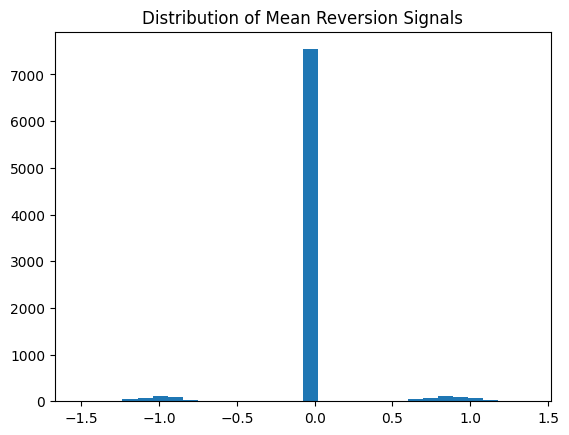

*   **What it represents:** This histogram shows the distribution of the calculated `Mean_Reversion_Signal`. This signal is a product of the Z-Score (price deviation from the mean) and a volatility adjustment factor derived from the ATR.
*   **What we could get from it:** It reveals the frequency and magnitude of trading signals. Most values are clustered at zero (no signal), while the spikes at the edges represent periods where the market was statistically overextended (overbought or oversold) according to the z-threshold.
*   **How the strategy performs:** A balanced distribution suggests the strategy finds an equal amount of long and short opportunities. The spread shows how much position sizes are being scaled by the volatility adjustment logic.

#### **2. Relationship Between Mean_Reversion_Signal and 5 Period % Change**

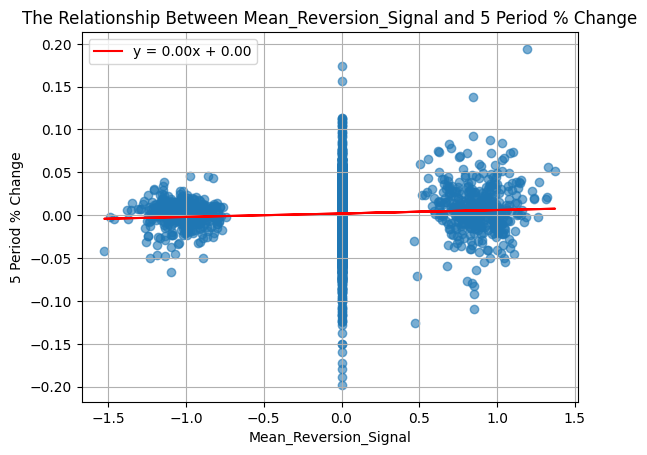

*   **What it represents:** This scatter plot maps the predictive relationship between the quantitative signal and the subsequent 5-day market return. The red line represents the OLS regression fit.
*   **What we could get from it:** The positive coefficient (0.0040) suggests that as our Mean Reversion Signal increases (indicating an oversold condition), the expected future return also increases. This is the core 'Alpha' assumption of the strategy.
*   **How the strategy performs:** While the P-value (0.000) indicates that the relationship is statistically significant, the low R-squared (0.002) warns that the signal only explains a tiny fraction of the total price variance, which is typical for high-frequency financial time series.

#### **3. Relationship Between Residuals and Predicted Values Scatter Plot**

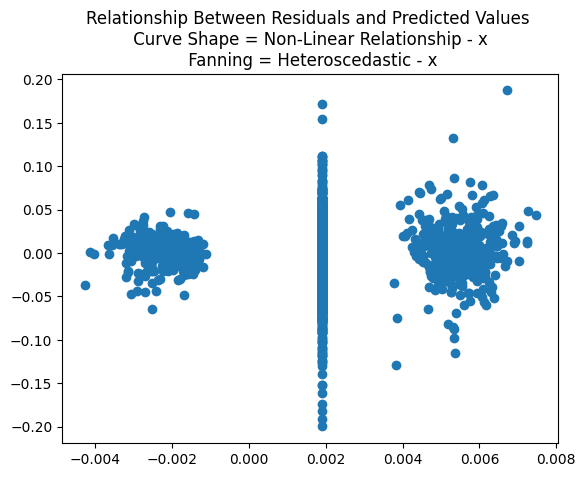

*   **What it represents:** This diagnostic plot checks if the model's errors (residuals) are independent of the predictions.
*   **What we could get from it:** Ideally, we want a random cloud. If we see a 'funnel' or 'curve', it means the model is failing to capture certain market dynamics or that the volatility is not constant (heteroscedasticity).
*   **How the strategy performs:** This helps us determine if a linear model is sufficient or if we need more complex non-linear logic (like machine learning) to capture mean reversion dynamics.

#### **4. Lag Plot of Residuals**

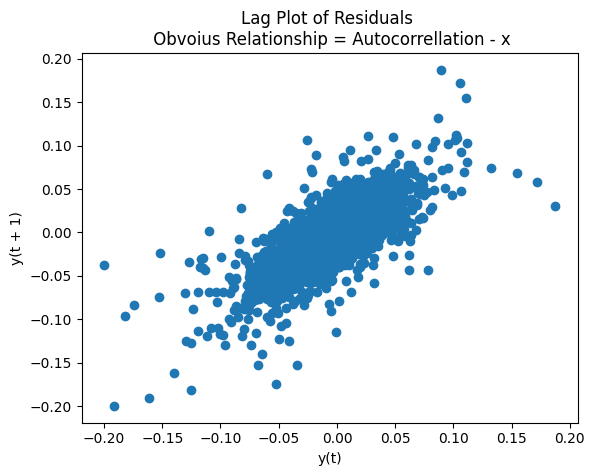

*   **What it represents:** This plot checks for autocorrelation by plotting the error of one period against the error of the previous period.
*   **What we could get from it:** An 'obvious relationship' (a diagonal line) would mean the model's mistakes are trending.
*   **How the strategy performs:** The Durbin-Watson statistic (0.473) and this plot suggest high positive autocorrelation. This indicates that price changes in the market are 'sticky', and our simple linear model isn't fully accounting for the time-series momentum of the $SPY$.

#### **5. Distribution of Residuals Histogram**

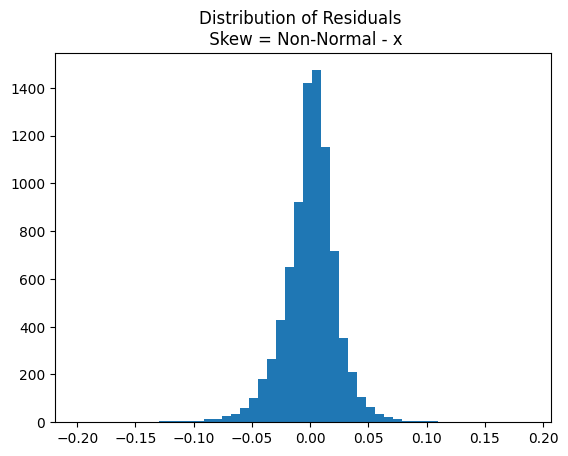

*   **What it represents:** This shows whether the model's errors are normally distributed.
*   **What we could get from it:** The high Kurtosis (9.06) and Skewness observed here indicate 'fat tails'.
*   **How the strategy performs:** This means the market experiences 'extreme events' much more often than a standard bell curve predicts. The strategy must be robust enough to handle these outliers, which is why the volatility adjustment (ATR) is included in the execution logic.

#### **6. Null Distribution of Correlation (Permutation Test)**

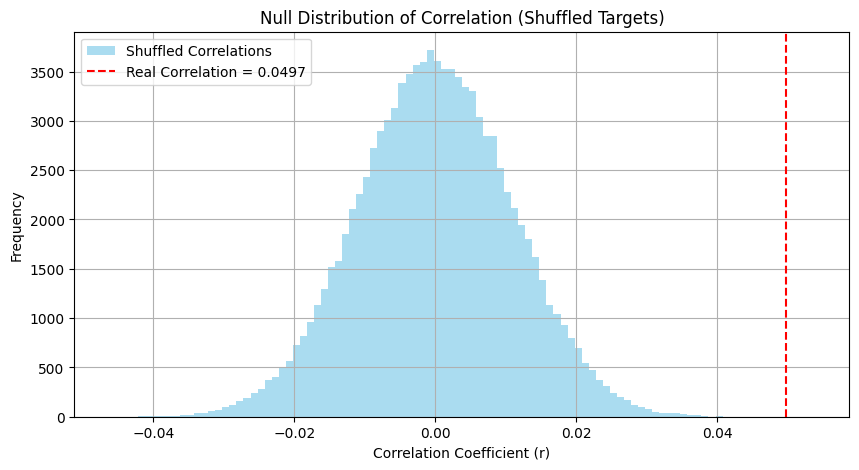

*   **What it represents:** This Monte Carlo simulation shuffles the returns 100,000 times to see what correlation could happen by pure luck.
*   **What we could get from it:** The 'Real Correlation' is compared against this 'Null Distribution'.
*   **How the strategy performs:** If the red dashed line is far in the tail of the blue histogram, we can be confident that our Mean Reversion signal isn't just a lucky coincidence. It provides a 'scientific' layer of validation beyond a simple backtest.

#### **7. Backtest Results & Equity Curve**

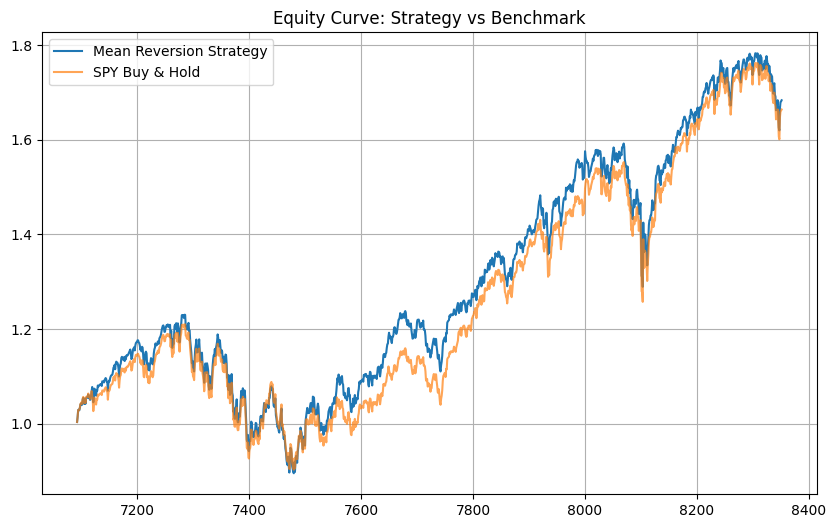

*   **What it represents:** The ultimate performance report of the strategy versus the $SPY$ Benchmark over the last 5 years.
*   **What we could get from it:**
    *   **Annualized Alpha (0.26%):** The strategy slightly outperformed the market on a pure return basis.
    *   **Sharpe Ratio (0.64):** Measures return per unit of risk.
    *   **Sortino Ratio (0.89):** Focuses specifically on 'bad' volatility.
*   **How the strategy performs:** The equity curve shows that the Mean Reversion strategy tracks the benchmark closely but with different risk characteristics. The volatility-adjusted position sizing helps smooth out the returns during turbulent periods compared to a static buy-and-hold approach.

### **Acknowledgments & Source**

The algorithmic framework for the Fair Value Gap (FVG) discretization and the permutation testing logic in this module is interpreted and adapted from the following open-source repository:
* Original Repository: [Statistical Significance of Fair Value Gaps](https://github.com/n84d/SharpEducation/blob/main/Regression/Reg_FVG.ipynb)
* Author: Sharp Research